In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

# Premiers aperçus
print("Shape du train :", train.shape)
print("Shape du test :", test.shape)
print("\n")
print(train.head())

Shape du train : (1460, 81)
Shape du test : (1459, 80)


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  S

Prix moyen : 180921.2
Prix médian : 163000.0
Prix min : 34900
Prix max : 755000


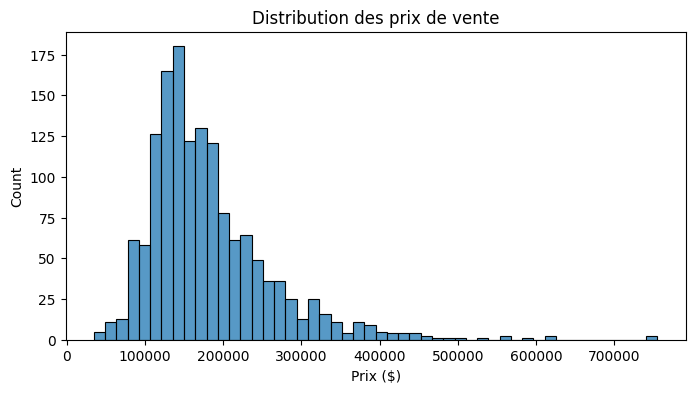

In [2]:
# Statistiques de base sur la variable cible (ce qu'on veut prédire)
print("Prix moyen :", round(train['SalePrice'].mean(), 2))   # moyenne des prix
print("Prix médian :", round(train['SalePrice'].median(), 2)) # médiane des prix
print("Prix min :", train['SalePrice'].min())                 # maison la moins chère
print("Prix max :", train['SalePrice'].max())                 # maison la plus chère

# Visualisation de la distribution des prix
plt.figure(figsize=(8, 4))         # taille du graphique (largeur, hauteur)
sns.histplot(train['SalePrice'], bins=50)  # histogramme avec 50 tranches de prix
plt.title("Distribution des prix de vente")
plt.xlabel("Prix ($)")
plt.show()

In [3]:
# Calcul des valeurs manquantes par colonne
missing = train.isnull().sum() # .isnull comptabilise les Nan et les None

# On garde uniquement les colonnes qui ont des valeurs manquantes
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Nombre de colonnes avec valeurs manquantes : {len(missing)}")
print("\n", missing)

Nombre de colonnes avec valeurs manquantes : 19

 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [4]:
# Calcul des valeurs manquantes par colonne
missing_count = train.isnull().sum()  # .sum sert à faire le total par colonne

# On garde uniquement les colonnes qui ont des valeurs manquantes
missing_cols = missing_count[missing_count > 0].sort_values(ascending=False) # avec "missing_count > 0" qui est un booléen

print(f"Nombre de colonnes avec valeurs manquantes : {len(missing_cols)}")
# ici len()donne le nbre d'éléments de la série, dc le nbre de lignes, dc le nbre de colonnes ac val manquantes
print("\n", missing_cols)

Nombre de colonnes avec valeurs manquantes : 19

 PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [5]:
def preprocess(df):
    df = df.copy() # pour se référencer à la copie et pas au train extérieur
    
    # Colonnes à supprimer (trop de manquants ou inutiles) : colonnes quasi vides apportent très peu d'informations
    cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'Id']
    df = df.drop(columns=cols_to_drop)
    
    # Colonnes texte où NaN veut dire "absence" → on remplace par "None"
    cols_none = ['FireplaceQu', 'GarageType', 'GarageFinish', 
                 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
                 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
    for col in cols_none:
        df[col] = df[col].fillna('None')
    
    # Colonnes numériques où NaN veut dire "absence" → on remplace par 0
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
    
    # Vraies valeurs manquantes → médiane ou mode. Mode = récupère la valeur la plus fréquente
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    
    # Encodage des colonnes texte en nombres
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col] = df[col].astype('category').cat.codes
    
    return df

train_clean = preprocess(train)
test_clean = preprocess(test)

print("Valeurs manquantes restantes :", train_clean.isnull().sum().sum())
print(train_clean.head())

Valeurs manquantes restantes : 0
   MSSubClass  MSZoning  LotFrontage  LotArea  Street  LotShape  LandContour  \
0          60         3         65.0     8450       1         3            3   
1          20         3         80.0     9600       1         3            3   
2          60         3         68.0    11250       1         0            3   
3          70         3         60.0     9550       1         0            3   
4          60         3         84.0    14260       1         0            3   

   Utilities  LotConfig  LandSlope  ...  EnclosedPorch  3SsnPorch  \
0          0          4          0  ...              0          0   
1          0          2          0  ...              0          0   
2          0          4          0  ...              0          0   
3          0          0          0  ...            272          0   
4          0          2          0  ...              0          0   

   ScreenPorch  PoolArea  MiscVal  MoSold  YrSold  SaleType  SaleCondit

In [6]:
def preprocess(df):
    df = df.copy() # pour modifier la copie et pas train à l'extérieur
    
    # Colonnes à supprimer (trop de manquants ou inutiles) : une colonne quasi vide apporte très peu d'informations
    cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'Id']
    df = df.drop(columns=cols_to_drop)
    
    # Colonnes texte où NaN veut dire "absence" → on remplace par "None"
    cols_none = ['FireplaceQu', 'GarageType', 'GarageFinish', 
                 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
                 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
    for col in cols_none:
        df[col] = df[col].fillna('None')
    
    # Colonnes numériques où NaN veut dire "absence" → on remplace par 0
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
    
    # Vraies valeurs manquantes → médiane ou mode
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
    # mode récupère la valeur la plus fréquente. On met [0] pour prendre la première au cas où il y en ait plusieurs ex aequo
    
    # Encodage des colonnes texte en nombres
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        df[col] = df[col].astype('category').cat.codes
        # Convertit la colonne en type "category" : un type pandas spécial
        # qui reconnaît que les valeurs sont des catégories (comme "Male"/"Female")
        # .cat c'est un accesseur : il dit à pandas "je veux accéder aux propriétés 
        # de cette colonne catégorielle"
        # .codes retourne un nombre entier pour chaque catégorie, 
        # attribué automatiquement par ordre alphabétique 
        # Ne stocke pas les associations : limite de cette méthode
    
    return df

train_clean = preprocess(train)
test_clean = preprocess(test)

print("Valeurs manquantes restantes :", train_clean.isnull().sum().sum())
print(train_clean.head())

Valeurs manquantes restantes : 0
   MSSubClass  MSZoning  LotFrontage  LotArea  Street  LotShape  LandContour  \
0          60         3         65.0     8450       1         3            3   
1          20         3         80.0     9600       1         3            3   
2          60         3         68.0    11250       1         0            3   
3          70         3         60.0     9550       1         0            3   
4          60         3         84.0    14260       1         0            3   

   Utilities  LotConfig  LandSlope  ...  EnclosedPorch  3SsnPorch  \
0          0          4          0  ...              0          0   
1          0          2          0  ...              0          0   
2          0          4          0  ...              0          0   
3          0          0          0  ...            272          0   
4          0          2          0  ...              0          0   

   ScreenPorch  PoolArea  MiscVal  MoSold  YrSold  SaleType  SaleCondit

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# On sépare les features (X) de la cible (y)
X = train_clean.drop(columns=['SalePrice'])
y = train_clean['SalePrice'] # on isole la colonne SalePrice

# On divise en set d'entraînement et set de validation (80/20) 
# Pour les features X, et la cible y
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# "train" est pour l'entrainement (80 %), "val" est pour la validation (20 %)
# "train_test_split" découpe en 2 morceaux (on ne peut pas changer le nom de la méthode)
# "test_size=0.2" pour dire que la 2eme partie fait 20%

# On crée et entraîne le modèle
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# "n_estimators" est le nombre d'arbres dans la foret. 100 est valeur standard pour commencer
# "random_state" est le générateur aléatoire

# On évalue
y_pred = model.predict(X_val)
# on lance .predict avec "X_val" :les 20 % qu'il n'a pas vu pendant l'entrainement
mae = mean_absolute_error(y_val, y_pred)  # comparaison entre y_val et y_pred
rmse = mean_squared_error(y_val, y_pred) ** 0.5  # comparaison entre y_val et y_pred
# on n'utilise pas accuracy_score car on ne peut pas calculer des bonnes réponses booléennes
# MAE : Mean Absolute Error : erreur moyenne des prédictions 
# RMSE : Root Mean Squared Error : autre erreur moyenne de prédiction, mais qui pénalise davantage 
# les grosses erreurs 

print("MAE  :", round(mae, 2), "$")
print("RMSE :", round(rmse, 2), "$")

# Lecture du résultat : le prix médian des maisons est 163 000, une erreur moyenne de 17465 représente 10 %
# ce qui est correct pour un premier modèle sans optimisation

MAE  : 17465.31 $
RMSE : 28342.03 $


In [8]:
# Prédictions sur le vrai set de test
predictions = model.predict(test_clean)

# Création du fichier de soumission
output = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': predictions
})

output.to_csv('submission.csv', index=False)
print("Fichier créé ! Aperçu :")
print(output.head(10))

# Le résultat de la compétition Kaggle est 0.14909 : plus le score est proche de zéron mieux c'est.

Fichier créé ! Aperçu :
     Id  SalePrice
0  1461  126433.33
1  1462  155510.00
2  1463  175530.68
3  1464  186348.85
4  1465  209476.47
5  1466  182696.00
6  1467  175254.40
7  1468  174793.97
8  1469  176626.55
9  1470  118887.00
